In [ ]:
#1 환경 설정 및 GCS 인증
from google.colab import auth
auth.authenticate_user() # # Google 계정으로 GCP 인증

PROJECT_ID = 'project-id'
BUCKET_NAME = 'sign-language-data-2026'

!gcloud config set project {PROJECT_ID} #  # gcloud CLI 프로젝트 설정

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].


In [ ]:
#2 GCS에서 데이터 로드
# X: (15000, 30, 274) — 3000단어 × 5각도 × 30프레임 × 274 키포인트
# y: (15000,) — 각 샘플의 단어 ID (0~2999)

import numpy as np
from google.cloud import storage

def download_from_gcs(bucket_name, blob_name, local_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(blob_name)
    blob.download_to_filename(local_path)
    print(f'Downloaded: {blob_name} → {local_path}')

download_from_gcs(BUCKET_NAME, 'processed/X_train.npy', '/content/X_train.npy')
download_from_gcs(BUCKET_NAME, 'processed/y_train.npy', '/content/y_train.npy')

X = np.load('/content/X_train.npy')  # (15000, 30, 274)
y = np.load('/content/y_train.npy')  # (15000,)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'클래스 수: {len(np.unique(y))}')

Downloaded: processed/X_train.npy → /content/X_train.npy
Downloaded: processed/y_train.npy → /content/y_train.npy
X shape: (15000, 30, 274)
y shape: (15000,)
클래스 수: 3000


In [ ]:
#3 데이터 전처리 및 분리
# Train/Val/Test 분리
# Z-score 정규화: 평균 0, 표준편차 1로 스케일 조정
# 분리 비율: 70% / 15% / 15%

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 정규화
X_mean = X.mean(axis=(0, 1), keepdims=True) # # shape: (1, 1, 274)
X_std  = X.std(axis=(0, 1), keepdims=True) + 1e-8 # 0 나눔 방지
X_norm = (X - X_mean) / X_std

# stratify 제거
X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y, test_size=0.30, random_state=42 # 70% train
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42 # temp를 절반씩 val/test
)

NUM_CLASSES = 3000
y_train_cat = to_categorical(y_train, NUM_CLASSES) # 원-핫 인코딩
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (10500, 30, 274), Val: (2250, 30, 274), Test: (2250, 30, 274)


In [ ]:
# 데이터 증강
# 과적합 방지

def augment(x):
    # 1. 노이즈 추가
    noise = np.random.normal(0, 0.01, x.shape) # 손 떨림 시뮬레이션
    # 2. 스케일 변형
    scale = np.random.uniform(0.9, 1.1) # 손 크기 변화 (90~110%)
    # 3. 이동
    shift = np.random.uniform(-0.05, 0.05) # 손 위치 이동
    return x * scale + noise + shift

# X_train 증강 (2배 추가 → 총 3배)
X_aug1 = np.array([augment(x) for x in X_train]) # 증강본 1
X_aug2 = np.array([augment(x) for x in X_train]) # 증강본 2

# 원본 + 증강 합치기
X_train_final = np.concatenate([X_train, X_aug1, X_aug2], axis=0)
y_train_final = np.concatenate([y_train, y_train, y_train], axis=0)
y_train_final_cat = to_categorical(y_train_final, NUM_CLASSES)

print(f'원본: {X_train.shape}')
print(f'증강 후: {X_train_final.shape}')

원본: (10500, 30, 274)
증강 후: (31500, 30, 274)


In [ ]:
#4  Transformer 모델 정의
#   Input (30, 274)
#   → Dense → (30, 128)       # 차원 축소 (projection)
#   → Positional Encoding      # 프레임 위치 정보 추가
#   → TransformerBlock × 3     # Self-Attention + FFN
#   → GlobalAveragePooling1D   # 30프레임 → 1벡터
#   → Dense(256) → Dense(3000, softmax)

import tensorflow as tf
from tensorflow.keras import layers, models

def positional_encoding(length, depth):
    positions = tf.range(length, dtype=tf.float32)[:, tf.newaxis]
    dims = tf.range(depth, dtype=tf.float32)[tf.newaxis, :]
    angles = positions / tf.pow(10000.0, (2 * (dims // 2)) / tf.cast(depth, tf.float32))
    angles = tf.concat([tf.sin(angles[:, 0::2]), tf.cos(angles[:, 1::2])], axis=-1)
    return angles[tf.newaxis, :, :]

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads) # 프레임 간 관계 학습
        self.ffn = models.Sequential([ 
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ]) # 위치별 비선형 변환
        self.norm1 = layers.LayerNormalization(epsilon=1e-6) # Attention 후 정규화
        self.norm2 = layers.LayerNormalization(epsilon=1e-6) # FFN 후 정규화
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.att(x, x)
        x = self.norm1(x + self.drop1(attn, training=training)) # 잔차 연결
        ffn = self.ffn(x)
        x = self.norm2(x + self.drop2(ffn, training=training)) # 잔차 연결
        return x

def build_transformer_model(input_shape=(30, 274), num_classes=3000,
                             embed_dim=128, num_heads=4, ff_dim=256,
                             num_blocks=3, dropout=0.1):
    inputs = layers.Input(shape=input_shape)

    # 입력 projection
    x = layers.Dense(embed_dim)(inputs)

    # Positional Encoding
    pos_enc = positional_encoding(input_shape[0], embed_dim)
    x = x + pos_enc

    # Transformer Blocks
    for _ in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout)(x)

    # Global Average Pooling → 시퀀스 압축
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model = build_transformer_model()
model.summary()
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 30, 274)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30, 128)        │        35,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 30, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 30, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 30, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3000)           │       771,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,236,664 (4.72 MB)

 Trainable params: 1,236,664 (4.72 MB)

 Non-trainable params: 0 (0.00 B)

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#5 학습
# Optimizer: Adam (lr=1e-3)
# Loss: Categorical Crossentropy
# 콜백:
# EarlyStopping: val_accuracy patience=10
# ReduceLROnPlateau: val_loss patience=5, factor=0.5
# ModelCheckpoint: val_accuracy 최고일 때 저장

from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history = model.fit(
    X_train_final, y_train_final_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 8.2031e-04 - loss: 7.8227 - top5_acc: 0.0039
Epoch 1: val_accuracy improved from None to 0.00000, saving model to /content/best_model.h5



Epoch 1: finished saving model to /content/best_model.h5
493/493 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.0013 - loss: 7.5073 - top5_acc: 0.0067 - val_accuracy: 0.0000e+00 - val_loss: 7.3223 - val_top5_acc: 0.0036 - learning_rate: 0.0010
Epoch 2/100
492/493 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0087 - loss: 6.2853 - top5_acc: 0.0371
Epoch 2: val_accuracy improved from 0.00000 to 0.00711, saving model to /content/best_model.h5



Epoch 2: finished saving model to /content/best_model.h5
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.0121 - loss: 6.0355 - top5_acc: 0.0491 - val_accuracy: 0.0071 - val_loss: 6.1429 - val_top5_acc: 0.0351 - learning_rate: 0.0010
Epoch 3/100
489/493 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0328 - loss: 5.1630 - top5_acc: 0.1223
Epoch 3: val_accuracy improved from 0.00711 to 0.03644, saving model to /content/best_model.h5



Epoch 3: finished saving model to /content/best_model.h5
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0397 - loss: 4.9602 - top5_acc: 0.1491 - val_accuracy: 0.0364 - val_loss: 5.1370 - val_top5_acc: 0.1378 - learning_rate: 0.0010
Epoch 4/100
489/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0873 - loss: 4.2321 - top5_acc: 0.2720
Epoch 4: val_accuracy improved from 0.03644 to 0.09689, saving model to /content/best_model.h5



Epoch 4: finished saving model to /content/best_model.h5
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1017 - loss: 4.0638 - top5_acc: 0.3084 - val_accuracy: 0.0969 - val_loss: 4.2800 - val_top5_acc: 0.3031 - learning_rate: 0.0010
Epoch 5/100
489/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1768 - loss: 3.4157 - top5_acc: 0.4547
Epoch 5: val_accuracy improved from 0.09689 to 0.16089, saving model to /content/best_model.h5


...


Epoch 31: finished saving model to /content/best_model.h5
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9906 - loss: 0.0311 - top5_acc: 0.9999 - val_accuracy: 0.7796 - val_loss: 1.5241 - val_top5_acc: 0.9293 - learning_rate: 2.5000e-04
Epoch 32/100
491/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9937 - loss: 0.0224 - top5_acc: 1.0000
Epoch 32: val_accuracy did not improve from 0.77956
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9940 - loss: 0.0221 - top5_acc: 1.0000 - val_accuracy: 0.7720 - val_loss: 1.5690 - val_top5_acc: 0.9244 - learning_rate: 2.5000e-04
Epoch 33/100
492/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9943 - loss: 0.0195 - top5_acc: 1.0000
Epoch 33: val_accuracy did not improve from 0.77956
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9927 - loss: 0.0234 - top5_acc: 1.0000 - val_accuracy: 0.7693 - val_loss: 1.6390 - val_top5_acc: 0.9307 - learning_rate: 2.5000e-04
Epoch 34/100
489/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accu


Epoch 36: finished saving model to /content/best_model.h5
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9961 - loss: 0.0158 - top5_acc: 1.0000 - val_accuracy: 0.7876 - val_loss: 1.5875 - val_top5_acc: 0.9316 - learning_rate: 1.2500e-04
Epoch 37/100
489/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9976 - loss: 0.0102 - top5_acc: 1.0000
Epoch 37: val_accuracy did not improve from 0.78756
493/493 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9977 - loss: 0.0102 - top5_acc: 1.0000 - val_accuracy: 0.7813 - val_loss: 1.5968 - val_top5_acc: 0.9320 - learning_rate: 1.2500e-04
Epoch 38/100
490/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9963 - loss: 0.0136 - top5_acc: 1.0000
Epoch 38: val_accuracy did not improve from 0.78756
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9965 - loss: 0.0128 - top5_acc: 1.0000 - val_accuracy: 0.7773 - val_loss: 1.6684 - val_top5_acc: 0.9289 - learning_rate: 1.2500e-04
Epoch 39/100
488/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - ac


Epoch 41: finished saving model to /content/best_model.h5
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9981 - loss: 0.0077 - top5_acc: 1.0000 - val_accuracy: 0.7929 - val_loss: 1.5813 - val_top5_acc: 0.9364 - learning_rate: 6.2500e-05
Epoch 42/100
492/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9980 - loss: 0.0075 - top5_acc: 1.0000
Epoch 42: val_accuracy did not improve from 0.79289
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9981 - loss: 0.0078 - top5_acc: 1.0000 - val_accuracy: 0.7902 - val_loss: 1.5743 - val_top5_acc: 0.9378 - learning_rate: 6.2500e-05
Epoch 43/100
492/493 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9984 - loss: 0.0067 - top5_acc: 1.0000
Epoch 43: val_accuracy did not improve from 0.79289
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9982 - loss: 0.0069 - top5_acc: 1.0000 - val_accuracy: 0.7871 - val_loss: 1.5998 - val_top5_acc: 0.9356 - learning_rate: 6.2500e-05
Epoch 44/100
492/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc


Epoch 44: finished saving model to /content/best_model.h5
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9983 - loss: 0.0061 - top5_acc: 1.0000 - val_accuracy: 0.7969 - val_loss: 1.5652 - val_top5_acc: 0.9351 - learning_rate: 6.2500e-05
Epoch 45/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9980 - loss: 0.0075 - top5_acc: 1.0000
Epoch 45: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 45: val_accuracy did not improve from 0.79689
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9983 - loss: 0.0073 - top5_acc: 1.0000 - val_accuracy: 0.7907 - val_loss: 1.5931 - val_top5_acc: 0.9351 - learning_rate: 6.2500e-05
Epoch 46/100
487/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9990 - loss: 0.0055 - top5_acc: 1.0000
Epoch 46: val_accuracy did not improve from 0.79689
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9989 - loss: 0.0054 - top5_acc: 1.0000 - val_accuracy: 0.7951 - val_loss: 1.5963 - val_top5_acc: 0.9351 - learnin


Epoch 49: finished saving model to /content/best_model.h5
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9988 - loss: 0.0050 - top5_acc: 1.0000 - val_accuracy: 0.7996 - val_loss: 1.5823 - val_top5_acc: 0.9364 - learning_rate: 3.1250e-05
Epoch 50/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9991 - loss: 0.0042 - top5_acc: 1.0000
Epoch 50: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 50: val_accuracy did not improve from 0.79956
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9992 - loss: 0.0042 - top5_acc: 1.0000 - val_accuracy: 0.7929 - val_loss: 1.6243 - val_top5_acc: 0.9351 - learning_rate: 3.1250e-05
Epoch 51/100
487/493 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9990 - loss: 0.0043 - top5_acc: 1.0000
Epoch 51: val_accuracy did not improve from 0.79956
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9990 - loss: 0.0044 - top5_acc: 1.0000 - val_accuracy: 0.7987 - val_loss: 1.5928 - val_top5_acc: 0.9351 - learn

Test Accuracy (Top-1): 0.8009
Test Accuracy (Top-5): 0.9329


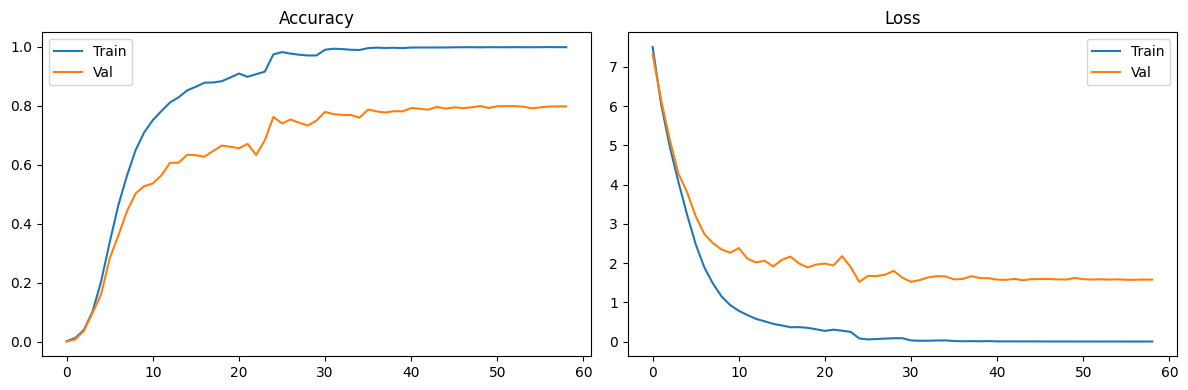

In [ ]:
#6 평가 및 시각화
import matplotlib.pyplot as plt

test_loss, test_acc, test_top5 = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test Accuracy (Top-1): {test_acc:.4f}') # 1등 예측이 정답인 비율
print(f'Test Accuracy (Top-5): {test_top5:.4f}') # 상위 5개 예측 안에 정답이 포함된 비율

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/training_curve.png', dpi=150)
plt.show()

In [ ]:
#7 GCS 저장
def upload_to_gcs(local_path, bucket_name, blob_name):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(blob_name)
    blob.upload_from_filename(local_path)
    print(f'Uploaded: {local_path} → gs://{bucket_name}/{blob_name}')

# 정규화 파라미터도 같이 저장 (추론 시 필수!)
np.save('/content/X_mean.npy', X_mean)
np.save('/content/X_std.npy',  X_std)

upload_to_gcs('/content/best_model.h5',      BUCKET_NAME, 'models/lstm_model.h5')
upload_to_gcs('/content/X_mean.npy',         BUCKET_NAME, 'models/X_mean.npy')
upload_to_gcs('/content/X_std.npy',          BUCKET_NAME, 'models/X_std.npy')
upload_to_gcs('/content/training_curve.png', BUCKET_NAME, 'models/training_curve.png')

print('GCS 업로드 완료')

Uploaded: /content/best_model.h5 → gs://sign-language-data-2026/models/lstm_model.h5
Uploaded: /content/X_mean.npy → gs://sign-language-data-2026/models/X_mean.npy
Uploaded: /content/X_std.npy → gs://sign-language-data-2026/models/X_std.npy
Uploaded: /content/training_curve.png → gs://sign-language-data-2026/models/training_curve.png
✅ GCS 업로드 완료


In [ ]:
#8 추론 테스트 (FastAPI 연동 전 확인용)
import json

download_from_gcs(BUCKET_NAME, 'processed/label_map.json', '/content/label_map.json')
with open('/content/label_map.json', 'r', encoding='utf-8') as f:
    label_map = json.load(f)  # key: '1'~'3000', value: 한글 단어

def predict_word(keypoints_30x274, top_k=5): # - predict_word(): (30, 274) 키포인트 입력 -> Top-K 예측 반환
    x = (keypoints_30x274 - X_mean[0]) / X_std[0] # 학습 때와 동일한 정규화
    x = x[np.newaxis, ...] # 배치 차원 추가 (1, 30, 274)
    probs = model.predict(x, verbose=0)[0]
    top_indices = probs.argsort()[-top_k:][::-1] # 확률 높은 순 정렬
    return [(label_map[str(i + 1)], float(probs[i])) for i in top_indices]

# 테스트
sample_raw = X_test[0] * X_std[0] + X_mean[0]
results = predict_word(sample_raw)

true_label = label_map[str(int(y_test[0]) + 1)]
print(f'정답: {true_label}')
print('예측 Top-5:')
for word, prob in results:
    mark = '○' if word == true_label else '  '
    print(f'  {mark} {word}: {prob:.4f}')

In [ ]:
#9 여러 샘플 테스트
correct = 0
for i in range(20):
    sample_raw = X_test[i] * X_std[0] + X_mean[0]
    results = predict_word(sample_raw)
    true_label = label_map[str(int(y_test[i]) + 1)]
    predicted = results[0][0]
    mark = '○' if predicted == true_label else 'x'
    print(f'{mark} 정답: {true_label} / 예측: {predicted}')
    if predicted == true_label:
        correct += 1

print(f'\n20개 중 {correct}개 정답 ({correct/20*100:.0f}%)')

In [ ]:
# GCS에서 모델 로드 후 가중치만 저장
download_from_gcs(BUCKET_NAME, 'models/lstm_model.h5', '/content/lstm_model.h5')
model.load_weights('/content/lstm_model.h5', by_name=False, skip_mismatch=False)
model.save_weights('/content/model_weights.weights.h5')

from google.colab import files
files.download('/content/model_weights.weights.h5')

Downloaded: models/lstm_model.h5 → /content/lstm_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>